In [1]:
# load the files
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_excel("/content/drive/MyDrive/Haystack/Result/manual_analysis_df.json.xlsx")

Mounted at /content/drive


In [2]:
df.head()

,method,qas_type,top_k,conv_ID,query_ID,precision of retrieval,recall of retrieval,F1 score of retrieval,precision of response,recall of response,F1 score of response
0,last_last,LDS,top_k=1,0,0,"[0.823355495929718, 0.823355495929718, 0.82335...","[0.8918161392211914, 0.8918161392211914, 0.891...","[0.8562195301055908, 0.8562195301055908, 0.856...",0.832109,0.889128,0.859674
1,last_last,LDS,top_k=1,0,1,"[0.8542726635932922, 0.8542726635932922, 0.854...","[0.8535438776016235, 0.8535438776016235, 0.853...","[0.8539080619812012, 0.8539080619812012, 0.853...",0.863988,0.805311,0.833618
2,last_last,LDS,top_k=1,0,2,"[0.8853918313980103, 0.8853918313980103, 0.885...","[0.8462538719177246, 0.8462538719177246, 0.846...","[0.865380585193634, 0.865380585193634, 0.86538...",0.879569,0.872328,0.875934
3,last_last,LDS,top_k=1,0,3,"[0.8770554065704346, 0.8770554065704346, 0.877...","[0.7880557775497437, 0.7880557775497437, 0.788...","[0.8301771283149719, 0.8301771283149719, 0.830...",0.858078,0.806111,0.831283
4,last_last,LDS,top_k=1,0,4,"[0.9999999403953552, 0.9999999403953552, 0.999...","[0.9999999403953552, 0.9999999403953552, 0.999...","[0.9999999403953552, 0.9999999403953552, 0.999...",0.957884,0.934887,0.946246


In [47]:
df["top_k"][0]

'top_k=1'

['last', 'all', 'rewrite']
[0.9158845094035079, 0.9125191924508299, 0.952325463209426]


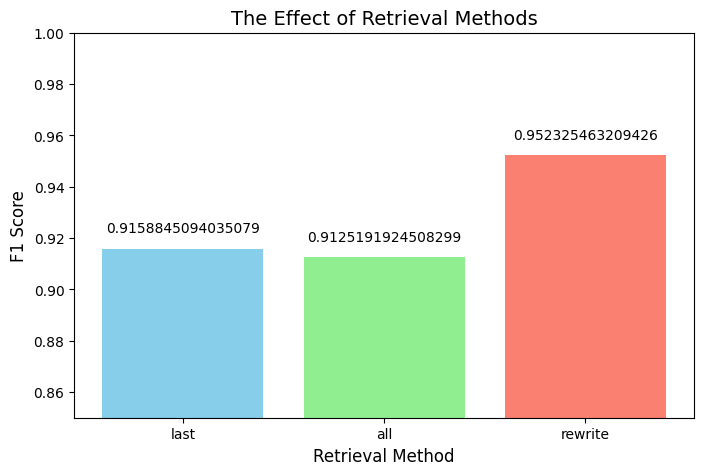

In [30]:
# The effect of retrieval method
import ast

x = ["last", "all", "rewrite"]
y = []
for retrieval_method in x:
  filtered_df = df[df["method"].str.startswith(retrieval_method)].copy()
  first_elements = filtered_df["F1 score of retrieval"].apply(lambda x: ast.literal_eval(x)[0])
  y.append(sum(first_elements)/len(first_elements))

print(x)
print(y)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

bars = plt.bar(x, y, color=['skyblue', 'lightgreen', 'salmon'])

plt.title('The Effect of Retrieval Methods', fontsize=14)
plt.xlabel('Retrieval Method', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0.85, 1.0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, yval, ha='center', va='bottom')
plt.show()

['last', 'all', 'rewrite']
[0.8931505969867014, 0.9024209163619571, 0.8860559594434857]


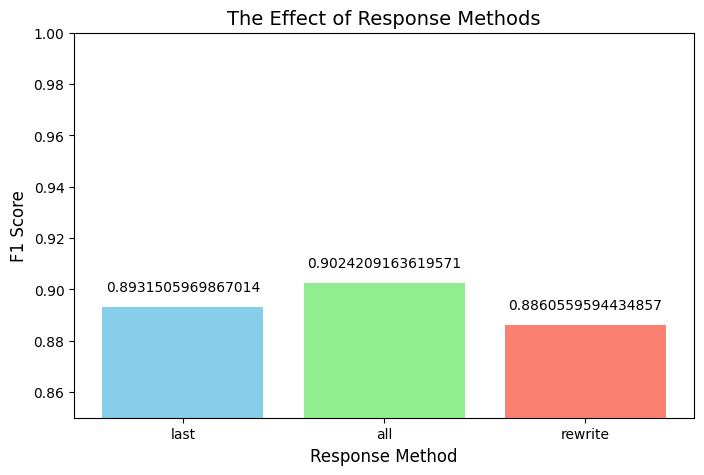

In [38]:
# The effect of response method
import ast

x = ["last", "all", "rewrite"]
y = []
for response_method in x:
  filtered_df = df[df["method"].str.endswith(response_method)].copy()
  first_elements = filtered_df["F1 score of response"].apply(lambda x: float(x))
  y.append(sum(first_elements)/len(first_elements))

print(x)
print(y)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

bars = plt.bar(x, y, color=['skyblue', 'lightgreen', 'salmon'])

plt.title('The Effect of Response Methods', fontsize=14)
plt.xlabel('Response Method', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0.85, 1.0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, yval, ha='center', va='bottom')
plt.show()

['top_k=1', 'top_k=3', 'top_k=5', 'top_k=10']
[0.879868962501608, 0.8927407027661043, 0.8988049866226618, 0.9035876575237509]


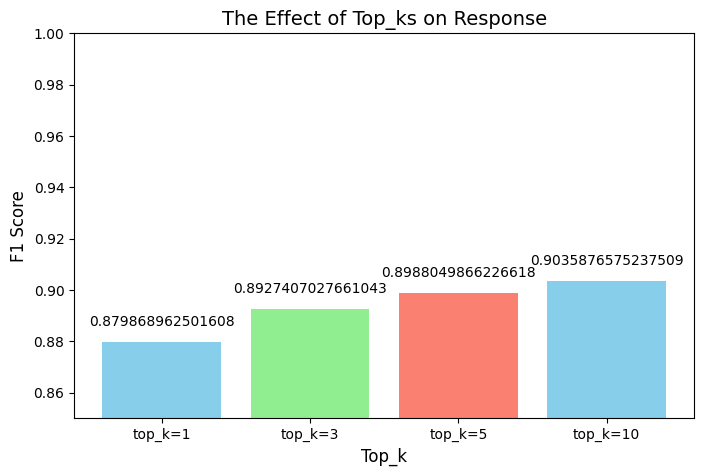

In [52]:
# The effect of top_k
import ast

x = ["top_k=1", "top_k=3", "top_k=5", "top_k=10"]
y = []
for top_k in x:
  filtered_df = df[df["top_k"] == top_k].copy()
  first_elements = filtered_df["F1 score of response"].apply(lambda x: float(x))
  y.append(sum(first_elements)/len(first_elements))

print(x)
print(y)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

bars = plt.bar(x, y, color=['skyblue', 'lightgreen', 'salmon'])

plt.title('The Effect of Top_ks on Response', fontsize=14)
plt.xlabel('Top_k', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0.85, 1.0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, yval, ha='center', va='bottom')
plt.show()

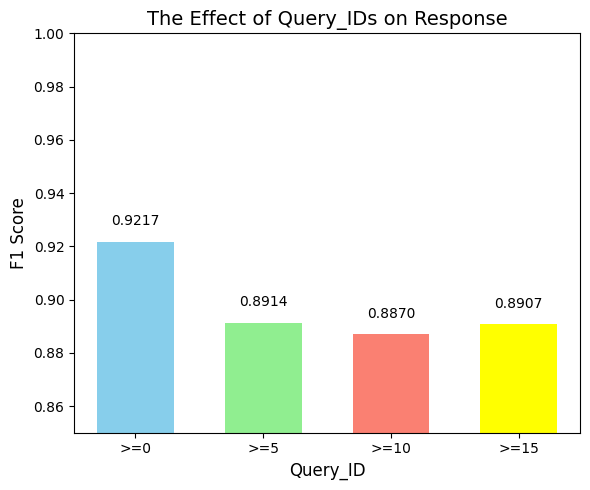

In [61]:
import matplotlib.pyplot as plt

x = [0, 5, 10, 15]
y = [] # Initialize y as an empty list
for query_ID in x:
  filtered_df = df[df["query_ID"] == query_ID].copy()
  first_elements = filtered_df["F1 score of response"].apply(lambda x: float(x))
  y.append(sum(first_elements)/len(first_elements))

x_labels = [">=0", ">=5", ">=10", ">=15"]

plt.figure(figsize=(6, 5))

bars = plt.bar(x_labels, y, width=0.6, color=['skyblue', 'lightgreen', 'salmon', 'yellow'])

plt.title('The Effect of Query_IDs on Response', fontsize=14)
plt.xlabel('Query_ID', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)

plt.ylim(0.85, 1.0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005,
             f'{yval:.4f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()